In [1]:
import tmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from faerun import Faerun
from rdkit import Chem
from rdkit.Chem import AllChem
from mhfp.encoder import MHFPEncoder
import tmap as tm

# TM-60 and CM-60 TMAPs - there may be a lot of deprecation warnings from AllChem, please ignore

In [2]:
tm60_train = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_NM-RS42.csv')
tm60_test = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv')

tm60_train['set'] = 'train'
tm60_test['set'] = 'test'

tm60_train_smi = tm60_train['Structure']
tm60_test_smi = tm60_test['Structure']

tm60_tr_label = tm60_train['set']
tm60_te_label = tm60_test['set']

tm60_tr_smi_clf = pd.concat([tm60_train_smi, tm60_train['Class']], axis=1)
tm60_te_smi_clf = pd.concat([tm60_test_smi, tm60_test['Class']], axis=1)

tm60_tr_smi_clf_lab = pd.concat([tm60_tr_smi_clf, tm60_tr_label], axis=1)
tm60_te_smi_clf_lab = pd.concat([tm60_te_smi_clf, tm60_te_label], axis=1)

tm60_full = pd.concat([tm60_tr_smi_clf_lab, tm60_te_smi_clf_lab], axis=0)


cm60_train = pd.read_csv(r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_training_set.csv')
cm60_test = pd.read_csv(r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_testing_set.csv')

cm60_train_smi = cm60_train['Structure']
cm60_test_smi = cm60_test['Structure']

cm60_train['set'] = 'train'
cm60_test['set'] = 'test'

cm60_tr_label = cm60_train['set']
cm60_te_label = cm60_test['set']

cm60_tr_smi_clf = pd.concat([cm60_train_smi, cm60_train['Class']], axis=1)
cm60_te_smi_clf = pd.concat([cm60_test_smi, cm60_test['Class']], axis=1)

cm60_tr_smi_clf_lab = pd.concat([cm60_tr_smi_clf, cm60_tr_label], axis=1)
cm60_te_smi_clf_lab = pd.concat([cm60_te_smi_clf, cm60_te_label], axis=1)

cm60_full = pd.concat([cm60_tr_smi_clf_lab, cm60_te_smi_clf_lab], axis=0)

In [3]:
def get_ecfp_fingerprint(mol, radius=3, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return list(fp)

def fingerprint_to_vectoruchar(fp):
     return tm.VectorUchar(fp)

# Load molecules
smiles_list = tm60_full['Structure']
mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerator
[13:06:16] DEPRECATION WARNING: please use MorganGenerat

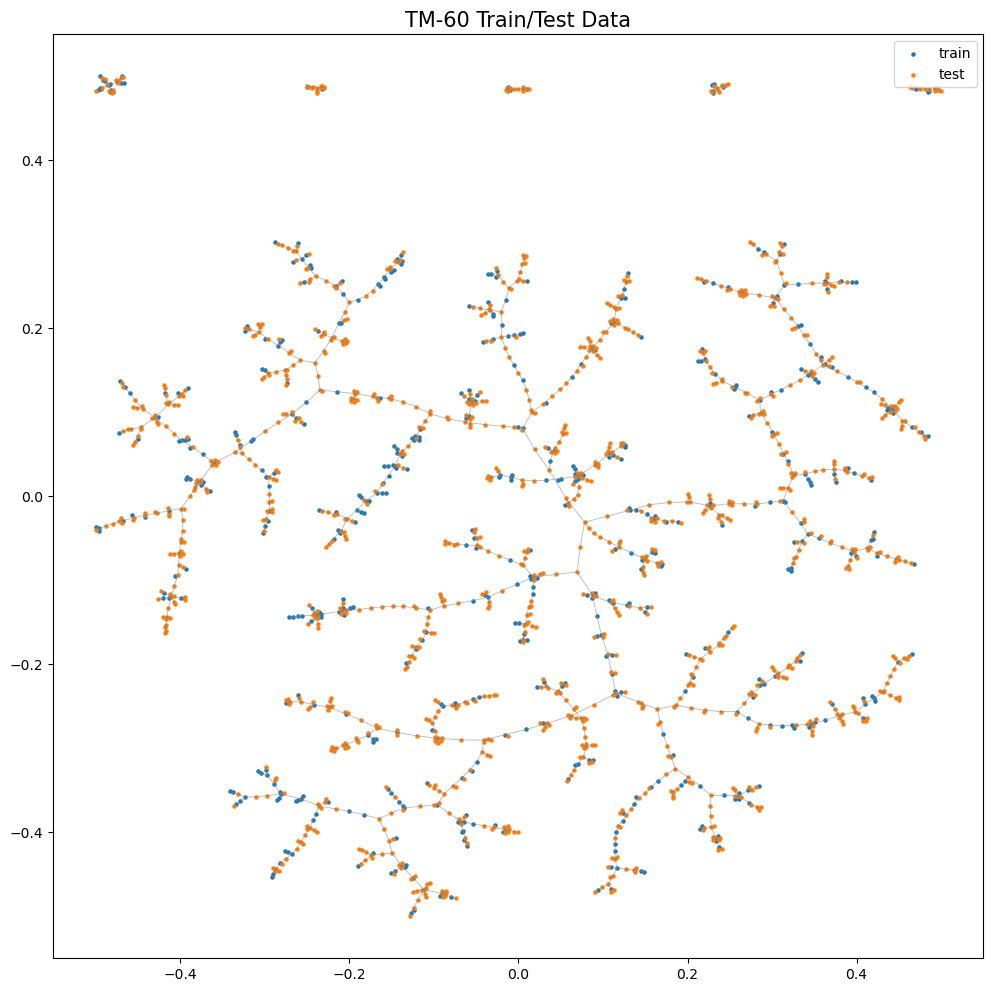

In [4]:
# Minhash & LSHForest
enc = tm.Minhash(512, seed=0)
lf = tm.LSHForest(512)

mh_list = []
for i, mol in enumerate(mols):
    if mol is None:
        continue

    fp = get_ecfp_fingerprint(mol)
    vec = fingerprint_to_vectoruchar(fp)

    mh = enc.from_binary_array(vec)
    lf.add(mh)
    mh_list.append(mh)

lf.index()

# Layout
cfg = tm.LayoutConfiguration()
x, y, s, t, _ = tm.layout_from_lsh_forest(lf, cfg)

label_map = {'train': 0,
                'test': 1}

plt.figure(figsize=(12,12))
plt.title("TM-60 Train Data", fontsize=15)

# Plot points /train
plt.scatter(x[0:524], y[0:524], s=5, label='train')

# Plot points /test
plt.scatter(x[524:], y[524:], s=5, label='test')

# plt.scatter(x, y)

# Plot edges
for start, end in zip(s, t):
    plt.plot([x[start], x[end]], [y[start], y[end]], color='gray', linewidth=0.7, alpha=0.5)

plt.title("TM-60 Train/Test Data", fontsize=15)
plt.legend()
plt.show()

In [5]:
tm60_conf = pd.read_csv(r'M:\ML_scripts\chemplot\tobramycin_full_preds_labelled.csv').drop(columns=['Unnamed: 0']).reset_index(drop=True)

# PLot TN/FN/FP/TP

[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerator
[13:07:24] DEPRECATION WARNING: please use MorganGenerat

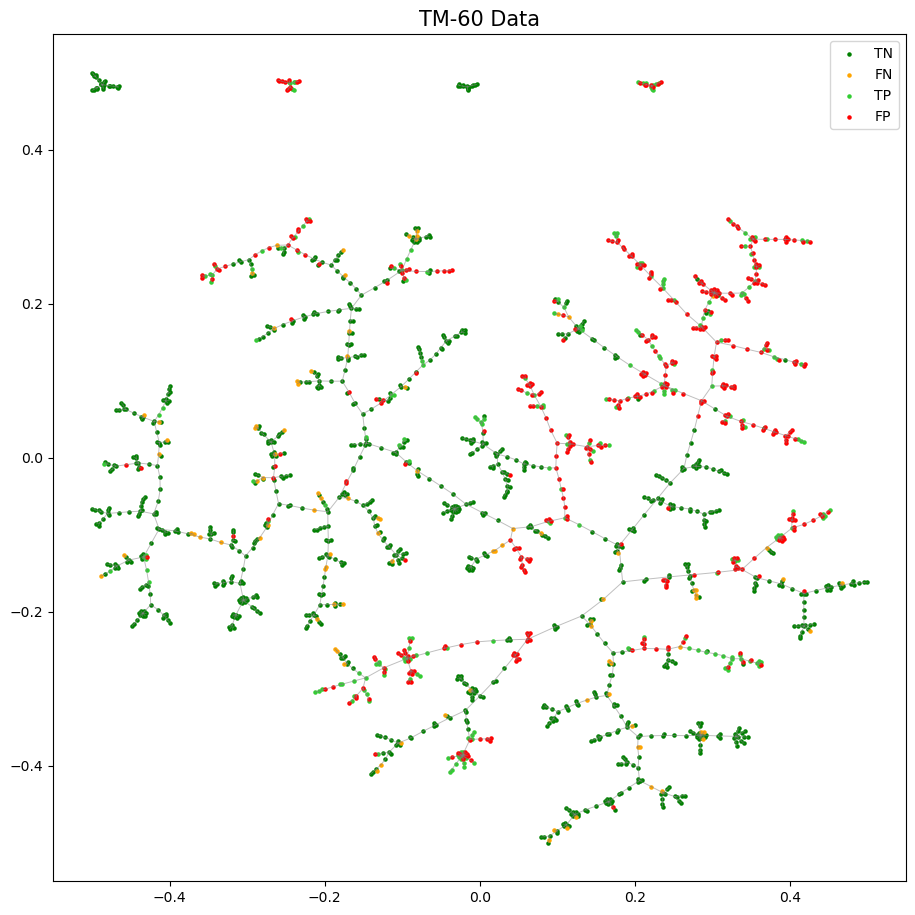

In [6]:
# Step 1: Load molecules
smiles_lst = tm60_conf['Structure']
mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_lst]

# # Step 2: Minhash & LSHForest

enc = tm.Minhash(512)
lf = tm.LSHForest(512)

mh_list = []
for i, mol in enumerate(mols):
    if mol is None:
        continue

    fp = get_ecfp_fingerprint(mol)
    vec = fingerprint_to_vectoruchar(fp)

    mh = enc.from_binary_array(vec)
    lf.add(mh)
    mh_list.append(mh)

lf.index()

# Step 3: Layout
cfg = tm.LayoutConfiguration()

x, y, s, t, _ = tmap.layout_from_lsh_forest(lf, cfg)

label_map = {'TN': 'TN',
                'FN': 'FN',
                'TP': 'TP',
                'FP': 'FP'}

labels = tm60_conf['Label']
labels_ = [label_map[label] for label in labels] 


plt.figure(figsize=(11,11))
plt.title("TM-60 Data", fontsize=15)

tn_mask = np.array(labels_) == 'TN'
fn_mask = np.array(labels_) == 'FN'
tp_mask = np.array(labels_) == 'TP'
fp_mask = np.array(labels_) == 'FP'

## plot each cluster of TN FN etc on separate axes

plt.scatter(np.array(x)[tn_mask], np.array(y)[tn_mask], color='green', s=5, label='TN')
plt.scatter(np.array(x)[fn_mask], np.array(y)[fn_mask], color='orange', s=5, label='FN')
plt.scatter(np.array(x)[tp_mask], np.array(y)[tp_mask], color='limegreen', s=5, label='TP')
plt.scatter(np.array(x)[fp_mask], np.array(y)[fp_mask], color='red', s=5, label='FP')

for start, end in zip(s, t):
    plt.plot([x[start], x[end]], [y[start], y[end]], color='gray', linewidth=0.7, alpha=0.5)

plt.legend()
plt.show()


# CM-60 TMAP

[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerator
[13:07:53] DEPRECATION WARNING: please use MorganGenerat

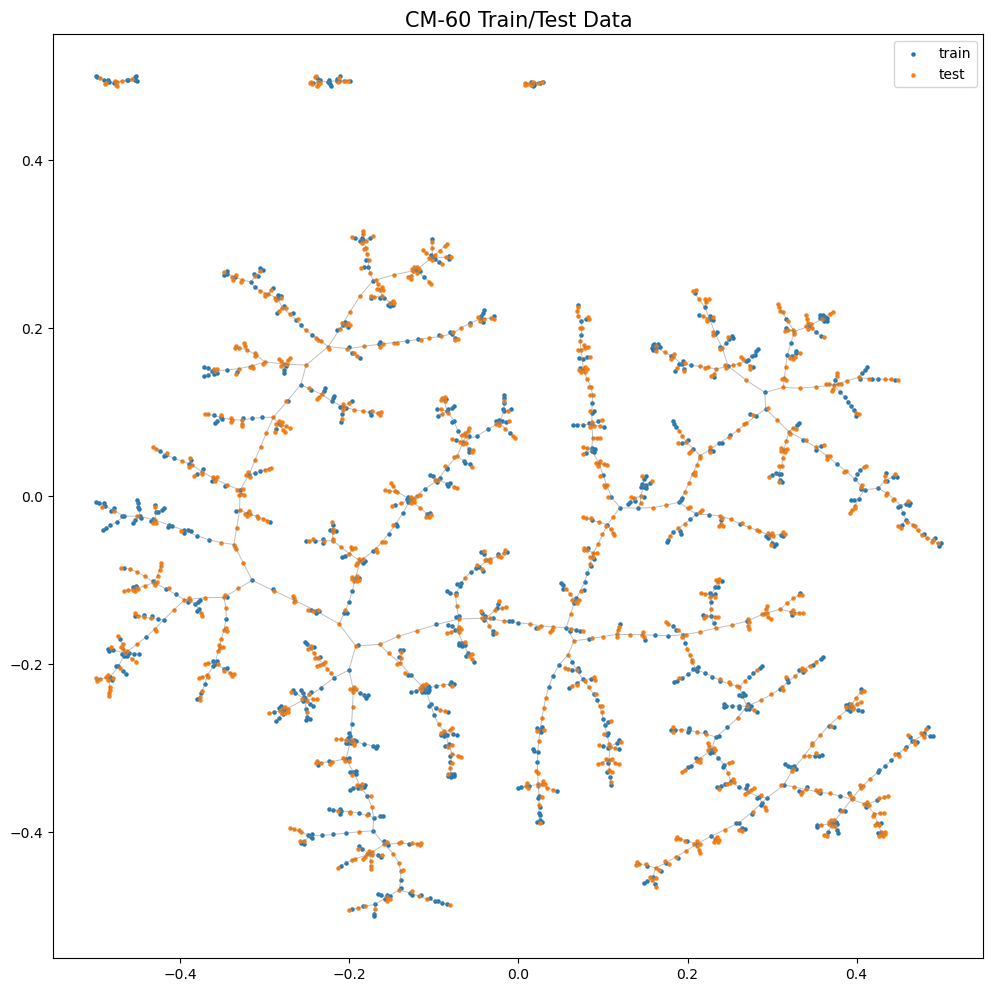

In [7]:
# col tmap

cm60_full = cm60_full.reset_index(drop=True)
c_mols = [Chem.MolFromSmiles(x) for x in cm60_full['Structure']]

# Minhash & LSHForest
enc = tm.Minhash(d=512, seed=0)
lf = tm.LSHForest(512)

mh_list = []
for i, mol in enumerate(c_mols):
    if mol is None:
        continue

    fp = get_ecfp_fingerprint(mol)
    vec = fingerprint_to_vectoruchar(fp)

    mh = enc.from_binary_array(vec)
    lf.add(mh)
    mh_list.append(mh)

lf.index()

# Layout
cfg = tm.LayoutConfiguration()
x, y, s, t, _ = tm.layout_from_lsh_forest(lf, cfg)

label_map = {'train': 0,
                'test': 1}

labels = cm60_full['set']
clf_labels = cm60_full['Class']
labels_int = [label_map[label] for label in labels]

plt.figure(figsize=(12,12))
plt.title("TM-60 Train Data", fontsize=15)

#Plot points /train
plt.scatter(x[0:890], y[0:890], s=5, label='train')

#Plot points /test
plt.scatter(x[890:], y[890:], s=5, label='test')

# plt.scatter(x, y)

# Plot edges
for start, end in zip(s, t):
    plt.plot([x[start], x[end]], [y[start], y[end]], color='gray', linewidth=0.7, alpha=0.5)

plt.title("CM-60 Train/Test Data", fontsize=15)
plt.legend()
plt.show()

these may not look the same as those in the report, the connectivity is the same but the projections change (for reasons unknown)